In [6]:
!pip install -q transformers accelerate torch torchvision pillow


# Load BLIP-2 Model

In [7]:
import torch
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Blip2Processor.from_pretrained(
    "Salesforce/blip2-flan-t5-xl"
)

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl",
    torch_dtype=torch.float16,
    device_map="auto"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [18]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Define the EXACT Prompt Template

In [19]:
prompt = """
You are an automotive damage assessment assistant.

You are given:
• A cropped image of a vehicle damage
• The detected damage type from an object detection model
• The damage area ratio relative to the full image

Your task:
1. Assess the severity of the damage.
2. Decide the required repair action.

Severity must be one of:
- Minor
- Moderate
- Severe

Repair action must be one of:
Dent:
- Dent pull only
- Dent pull + repaint
- Panel repair or replacement

Scratch:
- Polish only
- Repaint
- Fill and repaint

Damage type: dent
Area ratio: 0.037

Respond ONLY in JSON format:
{
  "severity": "<Minor | Moderate | Severe>",
  "repair_action": "<one valid action>",
  "confidence": "<0.0 – 1.0>"
}
"""


# Run VLM Inference

In [20]:
inputs = processor(
    images=image,
    text=prompt,
    return_tensors="pt"
).to(device, torch.float16)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=200
)

output = processor.decode(
    generated_ids[0],
    skip_special_tokens=True
)

print(output)


 "severity": "Minor | Moderate | Severe>", "repair_action": "one valid action>", "confidence": "0.0 – 1.0>"


# Automatically Detect Dent Area

Saving dent_01.jpeg to dent_01 (2).jpeg


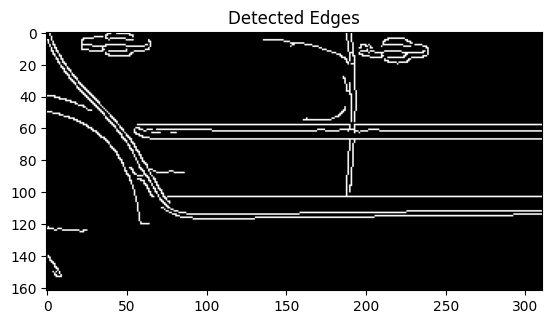

In [21]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# upload image
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# read image
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# blur to remove noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# detect edges
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Detected Edges")
plt.show()

# Find Dent Contour Automatically

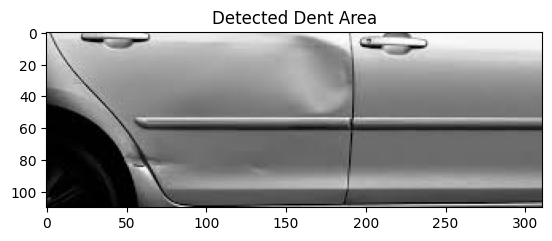

In [22]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# choose largest contour (assume dent)
largest = max(contours, key=cv2.contourArea)

x,y,w,h = cv2.boundingRect(largest)

dent = img[y:y+h, x:x+w]

plt.imshow(cv2.cvtColor(dent, cv2.COLOR_BGR2RGB))
plt.title("Detected Dent Area")
plt.show()

# Measure Dent Size

In [23]:
dent_area = w * h
print("Dent area:", dent_area)

Dent area: 34210


# Classify Dent Type / Repir cost

In [24]:
if dent_area < 5000:
    dent_type = "Small Dent"
    repair = "Paintless Dent Repair"
    cost = 5000

elif dent_area < 15000:
    dent_type = "Medium Dent"
    repair = "Panel Beating"
    cost = 12000

else:
    dent_type = "Severe Dent"
    repair = "Panel Replacement + Paint"
    cost = 25000

print("Dent Type:", dent_type)
print("Repair Needed:", repair)
print("Estimated Cost:", cost, "LKR")

Dent Type: Severe Dent
Repair Needed: Panel Replacement + Paint
Estimated Cost: 25000 LKR
